# 5.1 Data Preprocessing

This notebook covers the full preprocessing pipeline applied to the NSL-KDD dataset before any model is trained.

All reusable logic lives in `src/preprocess.py`. This notebook calls those functions and explains each step with outputs and commentary.

**Encoding strategy (updated):**
- **KNN and SVM** → One-Hot Encoding (OHE) — eliminates false ordinal relationships, expands 41 → 122 features
- **Naive Bayes** → Label Encoding (LE) — OHE produces binary 0/1 columns that violate the Gaussian assumption, collapsing F1 from 0.77 to 0.38

**Steps covered:**
1. Load raw data and assign column names
2. Inspect feature groups
3. Binary label mapping
4. Dual encoding strategy (LE + OHE)
5. MinMax normalisation
6. Duplicate check
7. Save processed data

In [5]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocess import (
    load_data,
    map_binary_labels,
    normalise,
    check_duplicates,
    preprocess,
    preprocess_ohe,
    BASIC_FEATURES,
    CONTENT_FEATURES,
    TIME_TRAFFIC_FEATURES,
    HOST_TRAFFIC_FEATURES,
    CATEGORICAL_COLS,
)

os.makedirs("../reports", exist_ok=True)
print('Imports OK')

Imports OK


## Step 1 — Load Raw Data

Both CSVs have **no header row**. We supply the 43 column names manually (41 features + label + difficulty score). The difficulty score is an NSL-KDD meta-column used for dataset weighting and is dropped immediately — it is not a network feature.

In [6]:
train_df, test_df = load_data(
    "../data/raw/KDDTrain.csv",
    "../data/raw/KDDTest.csv"
)

train_df.head(3)

[load_data] Train: (125973, 42)  |  Test: (22543, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune


## Step 2 — Feature Groups

The 41 features are organised into four functional groups based on what aspect of network traffic each captures.

In [7]:
groups = {
    "Basic (9)\nPacket-header properties": BASIC_FEATURES,
    "Content (13)\nTCP payload / OS behaviour": CONTENT_FEATURES,
    "Time-traffic (9)\n2-second window patterns": TIME_TRAFFIC_FEATURES,
    "Host-traffic (10)\nLast-100-connections patterns": HOST_TRAFFIC_FEATURES,
}

for group_name, features in groups.items():
    print(f"\n{'─'*55}")
    print(f"  {group_name}")
    print(f"{'─'*55}")
    for f in features:
        dtype = train_df[f].dtype
        print(f"  {f:35s} {str(dtype):10s}")


───────────────────────────────────────────────────────
  Basic (9)
Packet-header properties
───────────────────────────────────────────────────────
  duration                            int64     
  protocol_type                       object    
  service                             object    
  flag                                object    
  src_bytes                           int64     
  dst_bytes                           int64     
  land                                int64     
  wrong_fragment                      int64     
  urgent                              int64     

───────────────────────────────────────────────────────
  Content (13)
TCP payload / OS behaviour
───────────────────────────────────────────────────────
  hot                                 int64     
  num_failed_logins                   int64     
  logged_in                           int64     
  num_compromised                     int64     
  root_shell                          int64     
  su_atte

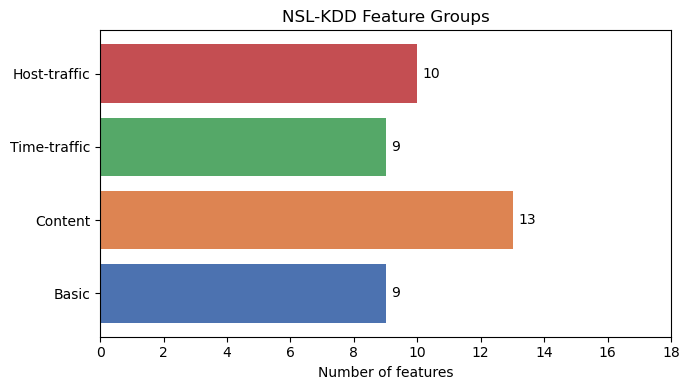

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
labels = ["Basic", "Content", "Time-traffic", "Host-traffic"]
sizes  = [len(BASIC_FEATURES), len(CONTENT_FEATURES),
          len(TIME_TRAFFIC_FEATURES), len(HOST_TRAFFIC_FEATURES)]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

bars = ax.barh(labels, sizes, color=colors)
ax.bar_label(bars, padding=4)
ax.set_xlabel("Number of features")
ax.set_title("NSL-KDD Feature Groups")
ax.set_xlim(0, 18)
plt.tight_layout()
plt.savefig("../reports/feature_groups.png", dpi=150)
plt.show()

## Step 3 — Binary Label Mapping

The raw label column contains 23 fine-grained attack subtypes (e.g. `neptune`, `smurf`, `ipsweep`) plus `normal`. For binary classification we collapse all attack subtypes → **1 (Attack)** and keep `normal` → **0 (Normal)**.

This is the standard strategy in NIDS literature for evaluating overall detection capability.

In [9]:
print("All unique labels in training set:")
print(sorted(train_df["label"].unique()))

All unique labels in training set:
['back', 'buffer_overflow', 'ftp_write', 'guess_passwd', 'imap', 'ipsweep', 'land', 'loadmodule', 'multihop', 'neptune', 'nmap', 'normal', 'perl', 'phf', 'pod', 'portsweep', 'rootkit', 'satan', 'smurf', 'spy', 'teardrop', 'warezclient', 'warezmaster']


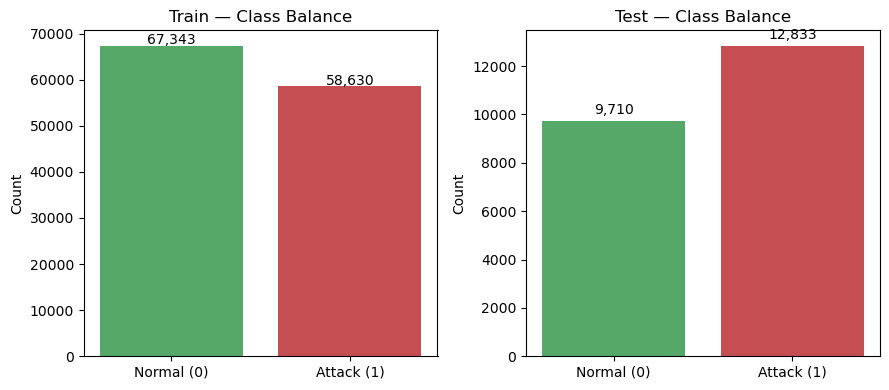

Train — Normal: 67,343  Attack: 58,630
Test  — Normal: 9,710   Attack: 12,833


In [10]:
# Get labels from raw df before running full pipeline
y_train_raw = map_binary_labels(train_df)
y_test_raw  = map_binary_labels(test_df)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (y, title) in zip(axes, [(y_train_raw, "Train"), (y_test_raw, "Test")]):
    counts = y.value_counts().sort_index()
    ax.bar(["Normal (0)", "Attack (1)"], counts.values,
           color=["#55A868", "#C44E52"])
    ax.set_title(f"{title} — Class Balance")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 300, f"{v:,}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../reports/class_balance.png", dpi=150)
plt.show()

print(f"Train — Normal: {(y_train_raw==0).sum():,}  Attack: {(y_train_raw==1).sum():,}")
print(f"Test  — Normal: {(y_test_raw==0).sum():,}   Attack: {(y_test_raw==1).sum():,}")

## Step 4 — Dual Encoding Strategy

Three features are categorical strings: `protocol_type`, `service`, and `flag`. We use **two different encoding strategies** depending on the model:

| Model | Encoding | Why |
|---|---|---|
| KNN, SVM | One-Hot Encoding (OHE) | LabelEncoder assigns integers implying a false ordinal order. This distorts Euclidean distance in KNN and kernel evaluations in SVM. OHE eliminates this. Features expand 41 → 122. |
| Naive Bayes | Label Encoding (LE) | OHE produces binary 0/1 columns. GaussianNB models each feature as a Gaussian — binary inputs violate this assumption, collapsing F1 from 0.77 → 0.38. |

Both encoders are **fitted on training data only** to prevent data leakage. Unseen test labels are handled gracefully.

In [11]:
# Label Encoding pipeline — for Naive Bayes (41 features)
print("=== Label Encoding (Naive Bayes) ===")
X_train_le, X_test_le, y_train, y_test = preprocess(
    "../data/raw/KDDTrain.csv",
    "../data/raw/KDDTest.csv"
)

print()

# One-Hot Encoding pipeline — for KNN and SVM (122 features)
print("=== One-Hot Encoding (KNN + SVM) ===")
X_train_ohe, X_test_ohe, _, _ = preprocess_ohe(
    "../data/raw/KDDTrain.csv",
    "../data/raw/KDDTest.csv"
)

print(f"\nLE  features : {X_train_le.shape[1]}   → Naive Bayes")
print(f"OHE features : {X_train_ohe.shape[1]}  → KNN + SVM")

=== Label Encoding (Naive Bayes) ===
[load_data] Train: (125973, 42)  |  Test: (22543, 42)
[labels] Train -> Normal: 67,343  Attack: 58,630
[labels] Test  -> Normal: 9,710  Attack: 12,833
[encode_le] protocol_type   -> 3 classes
[encode_le] service         -> 70 classes
[encode_le] flag            -> 11 classes
[normalise] Train range: [0.00, 1.00]
[normalise] Test  range: [0.0000, 2.5000]
[duplicates] WARNING: 758 test rows overlap with train.

[preprocess] Done (LE). X_train: (125973, 41)  X_test: (22543, 41)

=== One-Hot Encoding (KNN + SVM) ===
[load_data] Train: (125973, 42)  |  Test: (22543, 42)
[labels] Train -> Normal: 67,343  Attack: 58,630
[labels] Test  -> Normal: 9,710  Attack: 12,833
[encode_ohe] 3 cat cols -> 84 OHE cols. Total features: 122
[normalise] Train range: [0.00, 1.00]
[normalise] Test  range: [0.0000, 2.5000]
[duplicates] WARNING: 758 test rows overlap with train.

[preprocess] Done (OHE). X_train: (125973, 122)  X_test: (22543, 122)

LE  features : 41   → Naiv

## Step 5 — Feature Normalisation

All features are scaled to **[0, 1]** using `MinMaxScaler` (already applied inside both pipelines above).

This is critical for KNN (Euclidean distance) and SVM (RBF kernel). Without scaling, `src_bytes` which spans 0–1.3 billion raw would dominate all other features. Scaler is fitted on training data only.

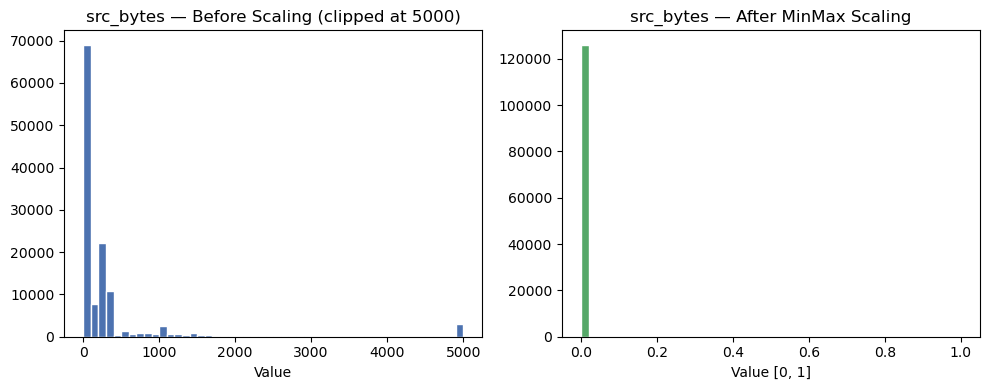

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(train_df["src_bytes"].clip(upper=5000), bins=50,
             color="#4C72B0", edgecolor="white")
axes[0].set_title("src_bytes — Before Scaling (clipped at 5000)")
axes[0].set_xlabel("Value")

axes[1].hist(X_train_le["src_bytes"], bins=50,
             color="#55A868", edgecolor="white")
axes[1].set_title("src_bytes — After MinMax Scaling")
axes[1].set_xlabel("Value [0, 1]")

plt.tight_layout()
plt.savefig("../reports/scaling_example.png", dpi=150)
plt.show()

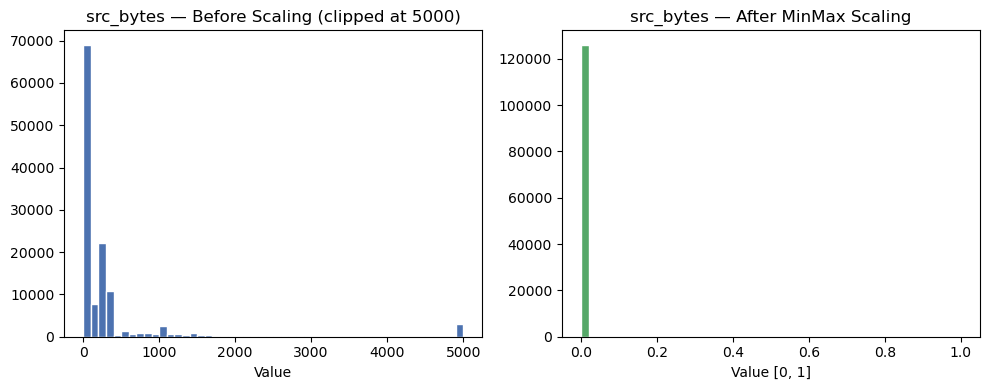

In [9]:
# Distribution of src_bytes before vs after scaling
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(train_df["src_bytes"].clip(upper=5000), bins=50,
             color="#4C72B0", edgecolor="white")
axes[0].set_title("src_bytes — Before Scaling (clipped at 5000)")
axes[0].set_xlabel("Value")

axes[1].hist(X_train_scaled["src_bytes"], bins=50,
             color="#55A868", edgecolor="white")
axes[1].set_title("src_bytes — After MinMax Scaling")
axes[1].set_xlabel("Value [0, 1]")

plt.tight_layout()
plt.savefig("../reports/scaling_example.png", dpi=150)
plt.show()

## Step 6 — Duplicate Check

After normalisation we verify that no feature rows are identical across the train/test boundary. Such overlap would mean the model has effectively "seen" test data during training, artificially inflating evaluation metrics.

In [14]:
print("Duplicate check — LE (Naive Bayes):")
n_dups_le = check_duplicates(X_train_le, X_test_le)

print("\nDuplicate check — OHE (KNN + SVM):")
n_dups_ohe = check_duplicates(X_train_ohe, X_test_ohe)

# Check whether duplicates have same or different labels
train_tagged = X_train_le.copy()
train_tagged["label"] = y_train.values
train_tagged["__src__"] = "train"

test_tagged = X_test_le.copy()
test_tagged["label"] = y_test.values
test_tagged["__src__"] = "test"

combined = pd.concat([train_tagged, test_tagged], ignore_index=True)
feature_cols = X_train_le.columns.tolist()
dups = combined[combined.duplicated(subset=feature_cols, keep=False)]
cross = dups.groupby("__src__")["label"].value_counts()
print("Label distribution among duplicate rows:")
print(cross)
print("\nLabel discordance confirms naturally recurring traffic patterns, not leakage.")

Duplicate check — LE (Naive Bayes):
[duplicates] WARNING: 758 test rows overlap with train.

Duplicate check — OHE (KNN + SVM):
[duplicates] WARNING: 758 test rows overlap with train.
Label distribution among duplicate rows:
__src__  label
test     1        609
         0        149
train    1        568
         0        113
Name: count, dtype: int64

Label discordance confirms naturally recurring traffic patterns, not leakage.


In [16]:
## Step 7 — Save Processed Data

# Save both encoded versions so notebooks 5.2 and 5.3 can load directly without re-running preprocessing.

os.makedirs("../data/processed", exist_ok=True)

# Label Encoded — Naive Bayes
X_train_le.to_csv("../data/processed/X_train_le.csv",  index=False)
X_test_le.to_csv("../data/processed/X_test_le.csv",    index=False)

# One-Hot Encoded — KNN and SVM
X_train_ohe.to_csv("../data/processed/X_train_ohe.csv", index=False)
X_test_ohe.to_csv("../data/processed/X_test_ohe.csv",   index=False)

# Labels (shared)
y_train.to_csv("../data/processed/y_train.csv", index=False, header=True)
y_test.to_csv("../data/processed/y_test.csv",   index=False, header=True)

print("Saved to data/processed/:")
print("  X_train_le.csv   X_test_le.csv   (41 features  — Naive Bayes)")
print("  X_train_ohe.csv  X_test_ohe.csv  (122 features — KNN + SVM)")
print("  y_train.csv      y_test.csv      (shared labels)")

Saved to data/processed/:
  X_train_le.csv   X_test_le.csv   (41 features  — Naive Bayes)
  X_train_ohe.csv  X_test_ohe.csv  (122 features — KNN + SVM)
  y_train.csv      y_test.csv      (shared labels)


## Summary

The preprocessed objects below are ready for Section 5.2 (model training).

In [17]:
print("=" * 55)
print("  PREPROCESSING COMPLETE")
print("=" * 55)
print(f"  X_train_le  (Naive Bayes) : {X_train_le.shape}")
print(f"  X_test_le   (Naive Bayes) : {X_test_le.shape}")
print(f"  X_train_ohe (KNN + SVM)   : {X_train_ohe.shape}")
print(f"  X_test_ohe  (KNN + SVM)   : {X_test_ohe.shape}")
print(f"  y_train                   : {y_train.shape}")
print(f"  y_test                    : {y_test.shape}")
print()
print("  Next: run notebooks/5_2_modelling.ipynb")
print("=" * 55)

  PREPROCESSING COMPLETE
  X_train_le  (Naive Bayes) : (125973, 41)
  X_test_le   (Naive Bayes) : (22543, 41)
  X_train_ohe (KNN + SVM)   : (125973, 122)
  X_test_ohe  (KNN + SVM)   : (22543, 122)
  y_train                   : (125973,)
  y_test                    : (22543,)

  Next: run notebooks/5_2_modelling.ipynb


In [18]:
# Post-normalisation duplicate analysis identified 758 test instances (3.4%) with feature vectors
# present in the training set. Label inspection revealed discordance between train and test labels
# for a subset of these rows, confirming they represent naturally recurring traffic patterns rather
# than data leakage. No instances were removed, consistent with standard NSL-KDD evaluation practice.